
# Solar Filament Segmentation — EDA

This notebook performs an extended exploratory analysis of the actual MAGFiLO solar-filament dataset used by the U-Net pipeline.

### EDA covered
1. Dataset and split statistics
2. Sample solar images
3. Original image resolution
4. Ground-truth masks
5. Image–mask pairs
6. Original → 512×512 preprocessing comparison
7. Pixel intensity distribution
8. Image brightness/contrast statistics
9. Filament-area distribution
10. Foreground/background imbalance
11. Train vs validation filament-area comparison
12. Observatory-station distribution
13. CLAHE preprocessing examples
14. Overlay visualization
15. Images with smallest/largest filament coverage
16. Duplicate filename/stem checks
17. Key observations for the first review

**No model training is performed in this notebook.**


## 1. Imports and paths

In [1]:

from pathlib import Path
import json
import random
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

RAW_DIR = Path(r"C:\Users\sivas\OneDrive\Desktop\vs code files\ML\MAGFiLO_1.0_Kaggle_2026")
PREPROCESSED_DIR = RAW_DIR / "preprocessed"

RAW_TRAIN_IMG_DIR = RAW_DIR / "train" / "train_images"
RAW_TEST_IMG_DIR = RAW_DIR / "test" / "test_images"

TRAIN_IMG_DIR = PREPROCESSED_DIR / "images_512" / "train"
VAL_IMG_DIR = PREPROCESSED_DIR / "images_512" / "val"
TEST_IMG_DIR = PREPROCESSED_DIR / "images_512" / "test"

TRAIN_MASK_DIR = PREPROCESSED_DIR / "masks_512" / "binary" / "train"
VAL_MASK_DIR = PREPROCESSED_DIR / "masks_512" / "binary" / "val"

TRAIN_CLAHE_DIR = PREPROCESSED_DIR / "images_clahe_512" / "train"
VAL_CLAHE_DIR = PREPROCESSED_DIR / "images_clahe_512" / "val"

METADATA_DIR = PREPROCESSED_DIR / "metadata"

print("Raw dataset:", RAW_DIR)
print("Preprocessed dataset:", PREPROCESSED_DIR)
print("Raw train images:", RAW_TRAIN_IMG_DIR.exists())
print("Preprocessed train images:", TRAIN_IMG_DIR.exists())


Raw dataset: C:\Users\sivas\OneDrive\Desktop\vs code files\ML\MAGFiLO_1.0_Kaggle_2026
Preprocessed dataset: C:\Users\sivas\OneDrive\Desktop\vs code files\ML\MAGFiLO_1.0_Kaggle_2026\preprocessed
Raw train images: True
Preprocessed train images: True


## 2. Dataset split overview

In [2]:

def image_files(folder):
    if not folder.exists():
        return []
    return sorted([
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg"}
    ])

def count_images(folder):
    return len(image_files(folder))

split_df = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Images": [
        count_images(TRAIN_IMG_DIR),
        count_images(VAL_IMG_DIR),
        count_images(TEST_IMG_DIR)
    ]
})

display(split_df)

print("\nProject dataset facts:")
print("Raw annotated train images : 707")
print("Preprocessed train images  :", count_images(TRAIN_IMG_DIR))
print("Validation images          :", count_images(VAL_IMG_DIR))
print("Held-out test images       :", count_images(TEST_IMG_DIR))
print("Original resolution        : 2048 × 2048")
print("Model input resolution     : 512 × 512")


,Split,Images
0,Train,566
1,Validation,141
2,Test,180



Project dataset facts:
Raw annotated train images : 707
Preprocessed train images  : 566
Validation images          : 141
Held-out test images       : 180
Original resolution        : 2048 × 2048
Model input resolution     : 512 × 512


## 3. Sample original solar images

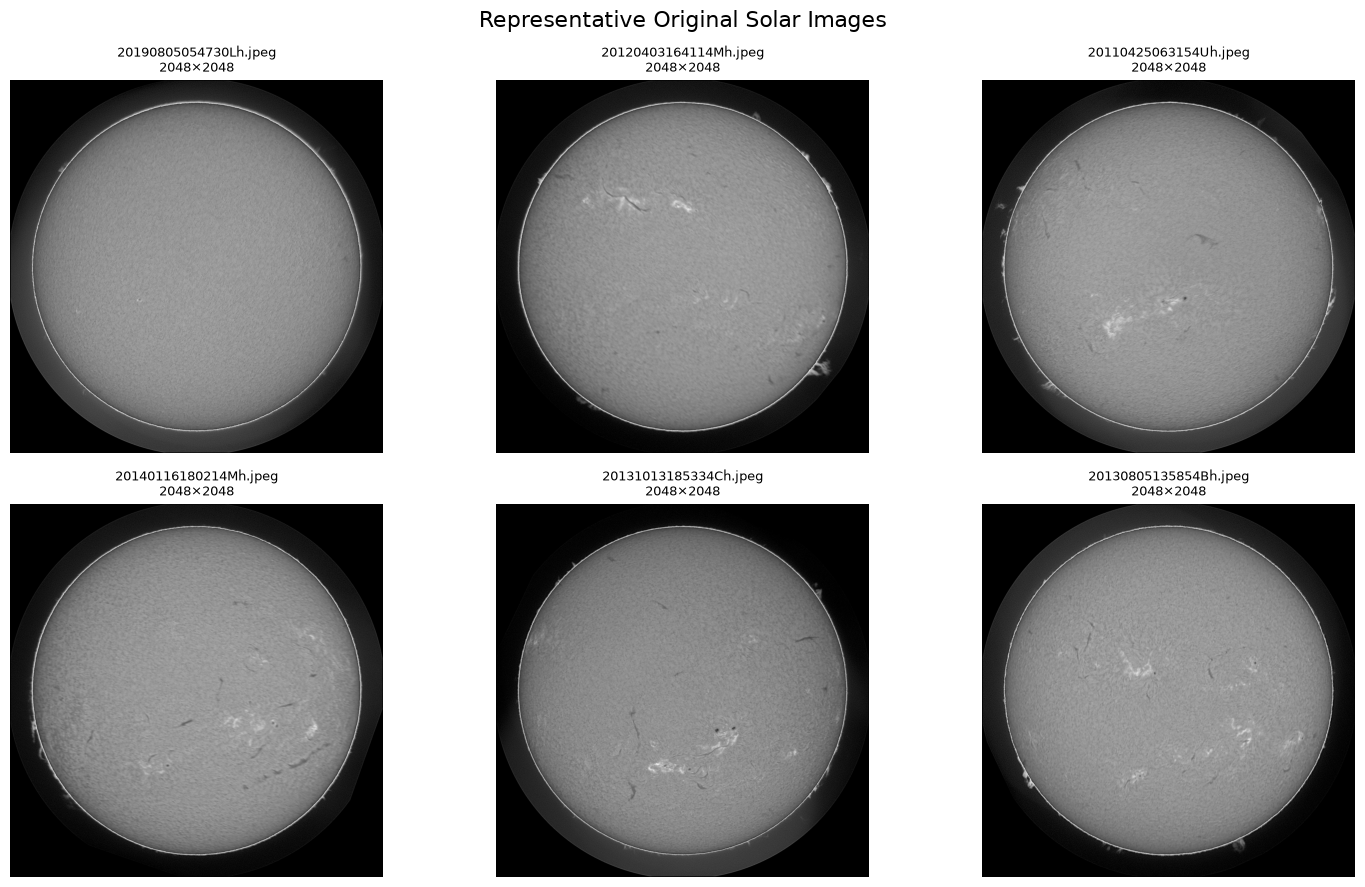

In [3]:

raw_train_images = image_files(RAW_TRAIN_IMG_DIR)

random.seed(42)
raw_samples = random.sample(raw_train_images, min(6, len(raw_train_images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, path in zip(axes.ravel(), raw_samples):
    img = Image.open(path).convert("L")
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{path.name}\n{img.size[0]}×{img.size[1]}", fontsize=9)
    ax.axis("off")

plt.suptitle("Representative Original Solar Images", fontsize=16)
plt.tight_layout()
plt.show()



### Observation
The raw training images are grayscale solar observations at **2048×2048** resolution.


## 4. Original image → preprocessed 512×512 image

Matched raw/preprocessed pairs: 566


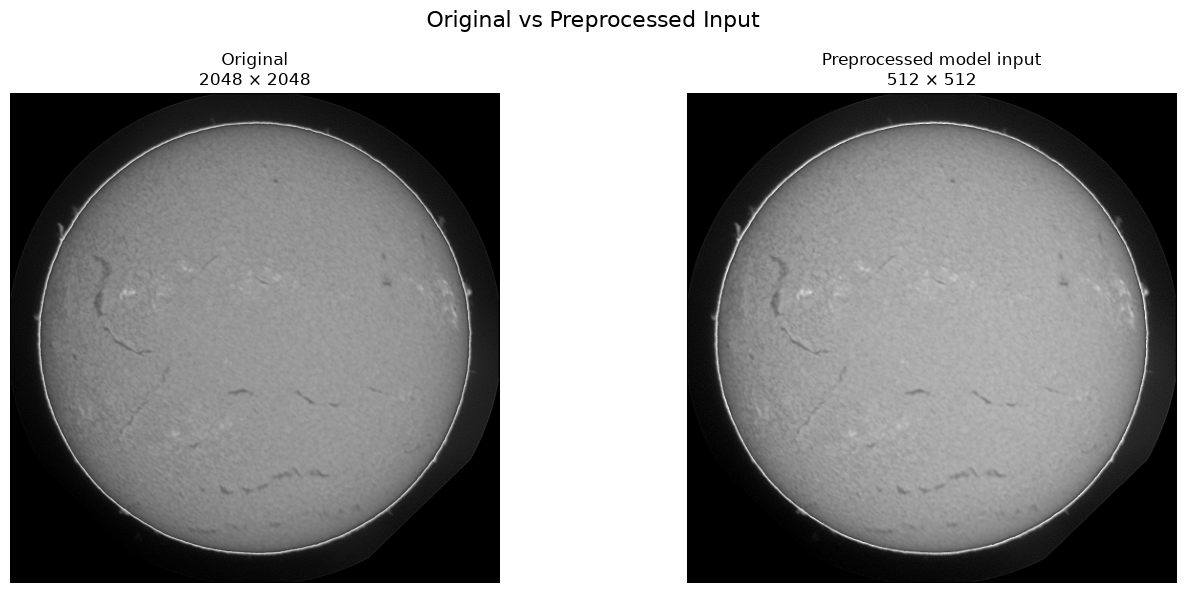

In [4]:

# Build a raw-image lookup by filename stem.
raw_lookup = {p.stem: p for p in raw_train_images}

train_images = image_files(TRAIN_IMG_DIR)
paired_raw_pre = []

for p512 in train_images:
    raw = raw_lookup.get(p512.stem)
    if raw is not None:
        paired_raw_pre.append((raw, p512))

print("Matched raw/preprocessed pairs:", len(paired_raw_pre))

if paired_raw_pre:
    raw_path, p512_path = random.choice(paired_raw_pre)

    raw_img = Image.open(raw_path).convert("L")
    pre_img = Image.open(p512_path).convert("L")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(raw_img, cmap="gray")
    axes[0].set_title(f"Original\n{raw_img.size[0]} × {raw_img.size[1]}")
    axes[0].axis("off")

    axes[1].imshow(pre_img, cmap="gray")
    axes[1].set_title(f"Preprocessed model input\n{pre_img.size[0]} × {pre_img.size[1]}")
    axes[1].axis("off")

    plt.suptitle("Original vs Preprocessed Input", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No raw/preprocessed filename matches were found.")



**Important:** This cell uses the actual raw image, so the original-resolution panel will no longer be blank.


## 5. Ground-truth binary masks

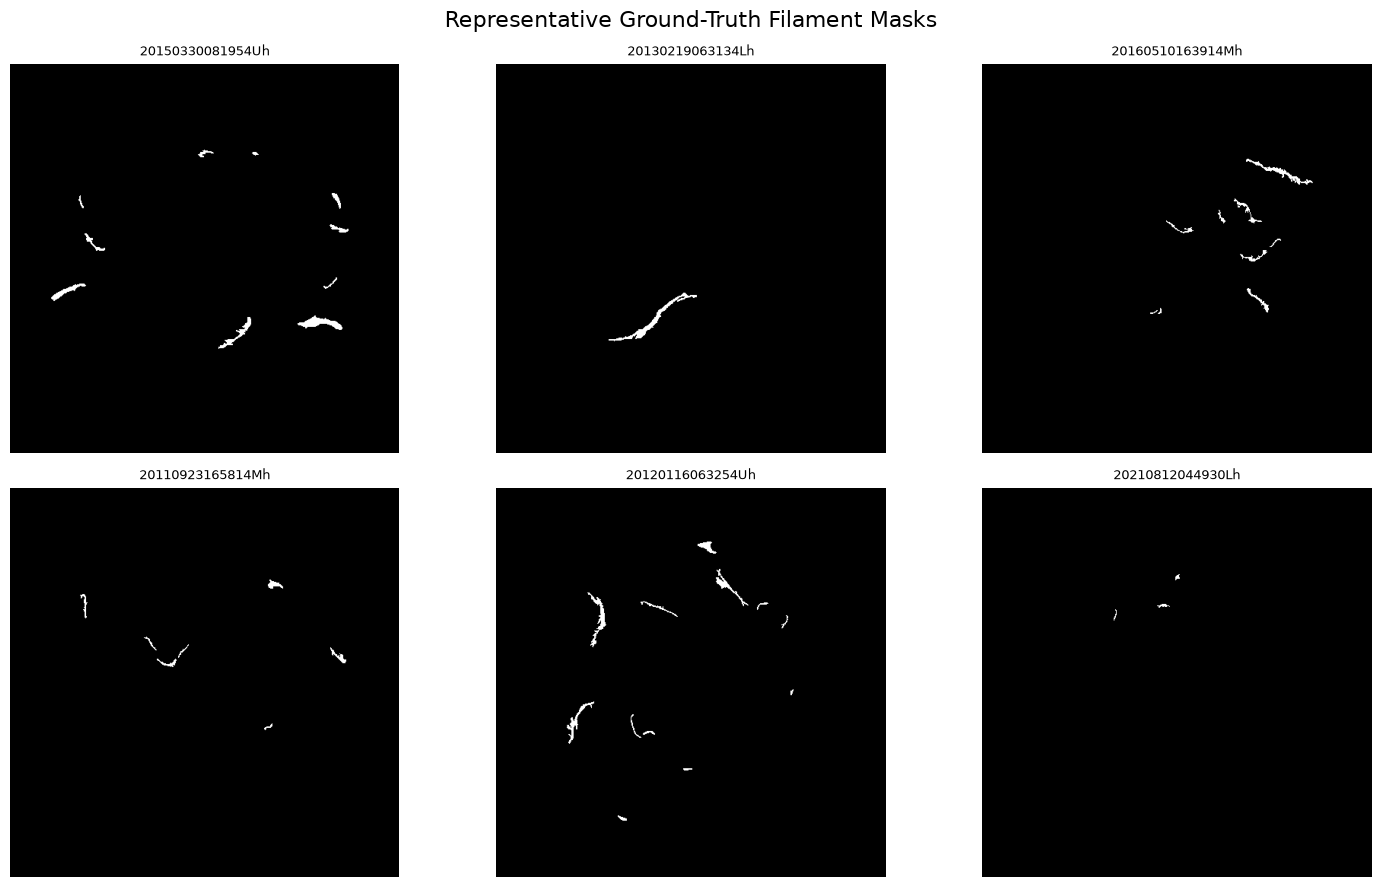

Unique values in first mask: [  0 255]


In [5]:

mask_files = image_files(TRAIN_MASK_DIR)
mask_lookup = {p.stem: p for p in mask_files}
paired = [(img, mask_lookup[img.stem]) for img in train_images if img.stem in mask_lookup]

random.seed(7)
sample_pairs = random.sample(paired, min(6, len(paired)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (_, mask_path) in zip(axes.ravel(), sample_pairs):
    mask = np.array(Image.open(mask_path))
    ax.imshow(mask, cmap="gray", vmin=0, vmax=255)
    ax.set_title(mask_path.stem, fontsize=9)
    ax.axis("off")

plt.suptitle("Representative Ground-Truth Filament Masks", fontsize=16)
plt.tight_layout()
plt.show()

print("Unique values in first mask:", np.unique(np.array(Image.open(sample_pairs[0][1]))))


## 6. Image + ground-truth mask pairs

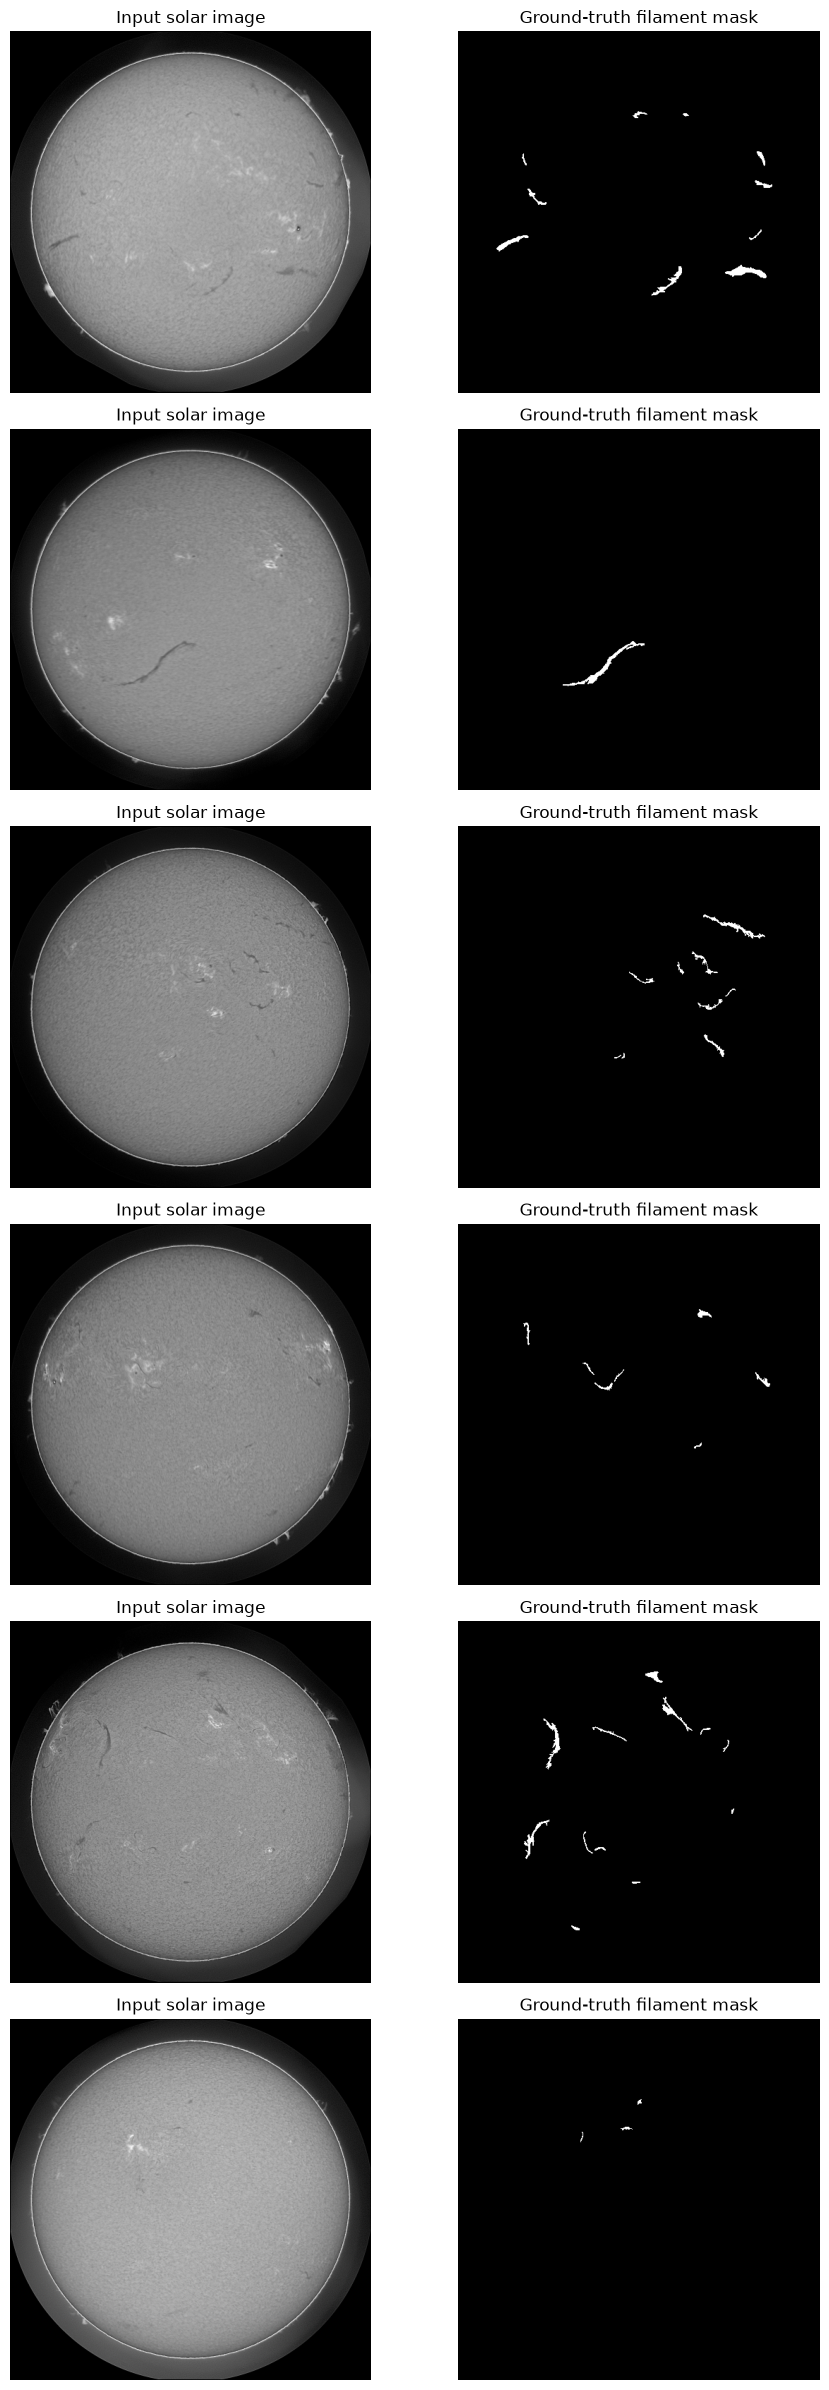

In [6]:

fig, axes = plt.subplots(len(sample_pairs), 2, figsize=(10, 4 * len(sample_pairs)))

if len(sample_pairs) == 1:
    axes = np.array([axes])

for i, (img_path, mask_path) in enumerate(sample_pairs):
    img = np.array(Image.open(img_path).convert("L"))
    mask = np.array(Image.open(mask_path))

    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title("Input solar image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray", vmin=0, vmax=255)
    axes[i, 1].set_title("Ground-truth filament mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


## 7. Ground-truth overlay visualization

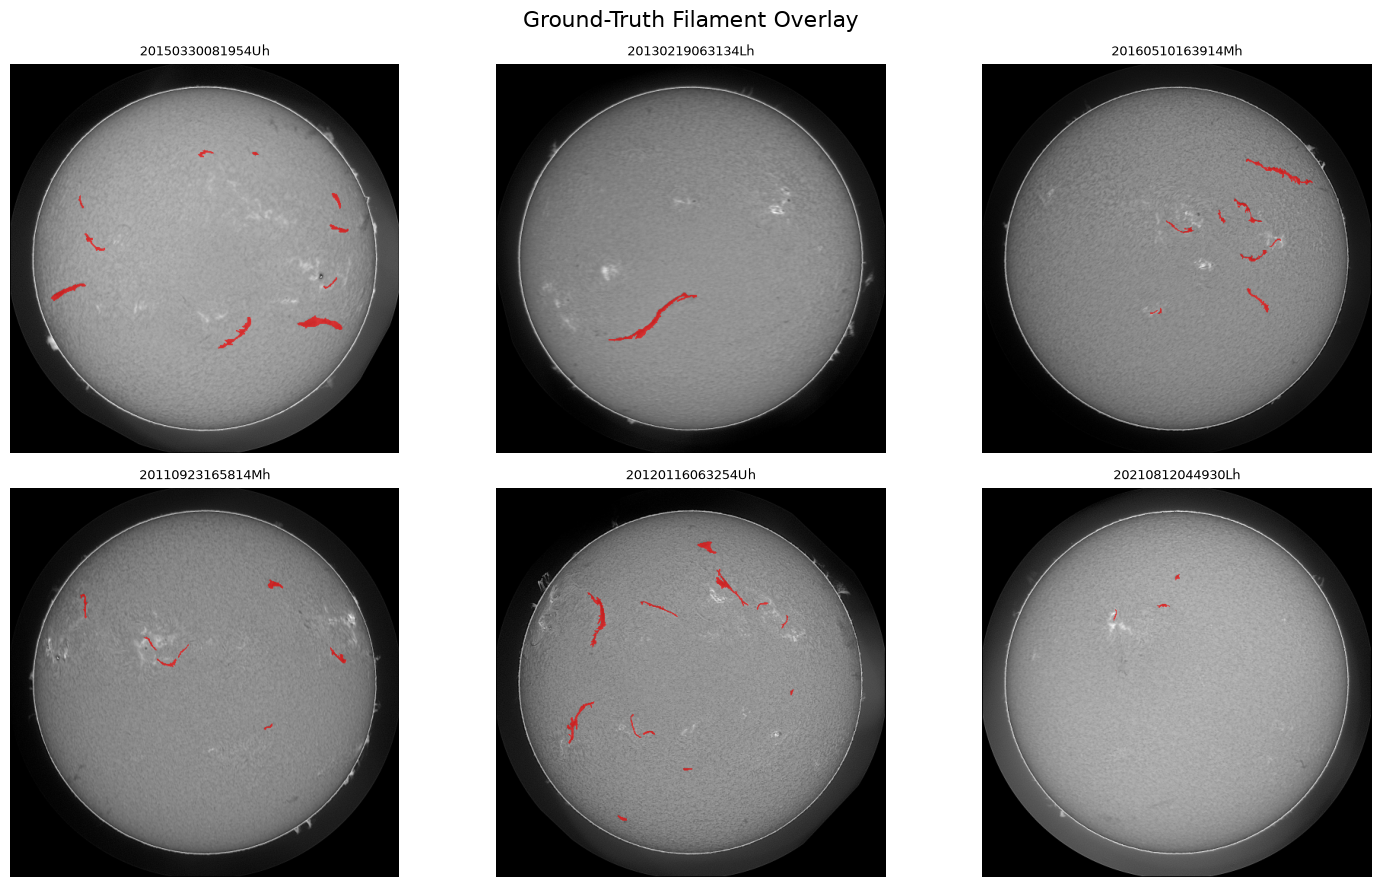

In [7]:

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (img_path, mask_path) in zip(axes.ravel(), sample_pairs):
    img = np.array(Image.open(img_path).convert("L"))
    mask = np.array(Image.open(mask_path)) > 0

    ax.imshow(img, cmap="gray")
    overlay = np.zeros((*mask.shape, 4))
    overlay[..., 0] = 1.0
    overlay[..., 3] = mask.astype(float) * 0.65
    ax.imshow(overlay)

    ax.set_title(img_path.stem, fontsize=9)
    ax.axis("off")

plt.suptitle("Ground-Truth Filament Overlay", fontsize=16)
plt.tight_layout()
plt.show()


## 8. Pixel-intensity distribution

Sampled pixel count: 3145728
Mean intensity: 83.18851884206136
Std intensity: 57.31526136900407
Min intensity: 0
Max intensity: 229


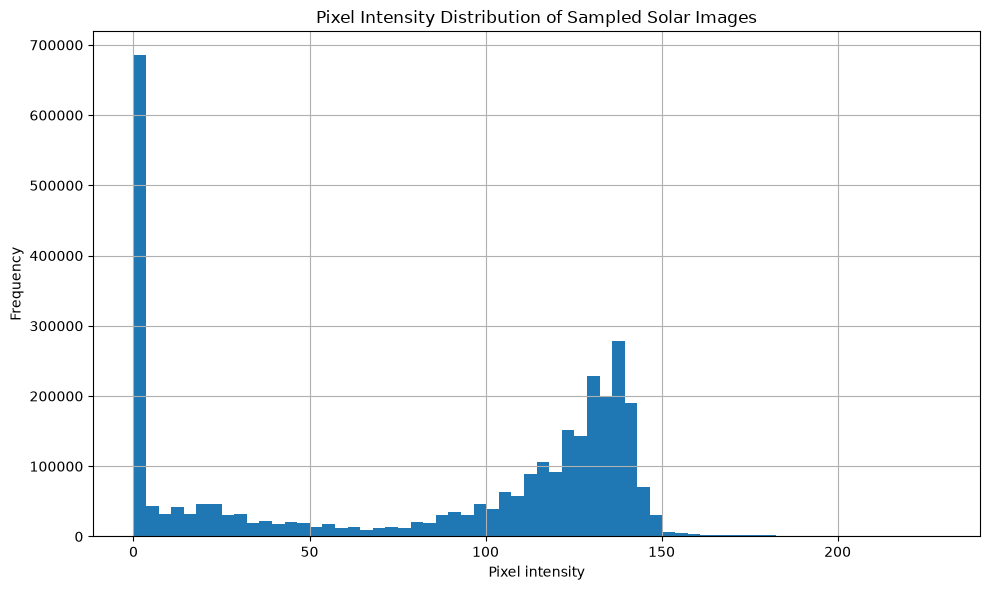

In [8]:

# Sample up to 12 images to keep the histogram lightweight.
random.seed(21)
intensity_samples = random.sample(train_images, min(12, len(train_images)))

pixels = []
for p in intensity_samples:
    arr = np.array(Image.open(p).convert("L"), dtype=np.uint8)
    pixels.append(arr.ravel())

pixels = np.concatenate(pixels)

print("Sampled pixel count:", len(pixels))
print("Mean intensity:", pixels.mean())
print("Std intensity:", pixels.std())
print("Min intensity:", pixels.min())
print("Max intensity:", pixels.max())

plt.figure(figsize=(10, 6))
plt.hist(pixels, bins=64)
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.title("Pixel Intensity Distribution of Sampled Solar Images")
plt.tight_layout()
plt.show()


## 9. Per-image brightness and contrast statistics

,mean_intensity,std_intensity,min_intensity,max_intensity
count,566.000000,566.000000,566.0,566.000000
mean,83.365768,56.312382,0.0,218.319794
std,3.140267,2.633065,0.0,16.133904
min,76.885956,48.668648,0.0,183.000000
25%,81.056408,54.821985,0.0,207.000000
50%,82.539658,57.257833,0.0,212.000000
75%,85.181604,58.257991,0.0,227.000000
max,95.492142,61.084450,0.0,255.000000


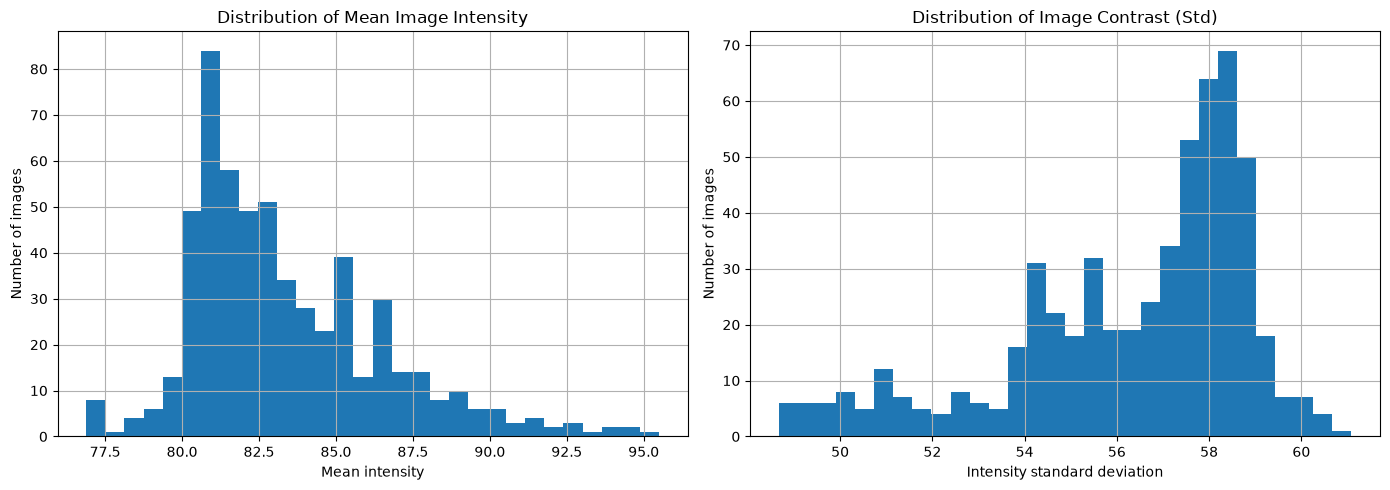

In [9]:

stats_rows = []

for p in train_images:
    arr = np.array(Image.open(p).convert("L"), dtype=np.float32)
    stats_rows.append({
        "image": p.name,
        "mean_intensity": arr.mean(),
        "std_intensity": arr.std(),
        "min_intensity": arr.min(),
        "max_intensity": arr.max()
    })

image_stats_df = pd.DataFrame(stats_rows)

display(image_stats_df.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(image_stats_df["mean_intensity"], bins=30)
axes[0].set_title("Distribution of Mean Image Intensity")
axes[0].set_xlabel("Mean intensity")
axes[0].set_ylabel("Number of images")

axes[1].hist(image_stats_df["std_intensity"], bins=30)
axes[1].set_title("Distribution of Image Contrast (Std)")
axes[1].set_xlabel("Intensity standard deviation")
axes[1].set_ylabel("Number of images")

plt.tight_layout()
plt.show()


## 10. Filament-area distribution

count    566.000000
mean       0.387593
std        0.290479
min        0.009155
25%        0.146484
50%        0.336266
75%        0.554657
max        1.570129
Name: filament_area_percent, dtype: float64

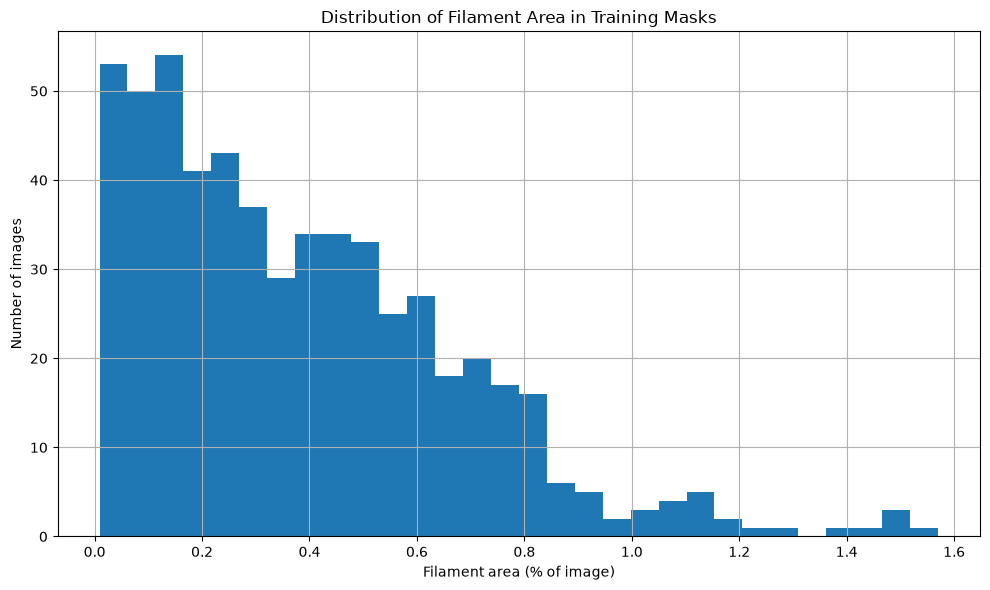

In [10]:

def filament_area_percent(mask_path):
    mask = np.array(Image.open(mask_path))
    return 100.0 * np.count_nonzero(mask > 0) / mask.size

area_rows = [
    {"image": img.name, "filament_area_percent": filament_area_percent(mask)}
    for img, mask in paired
]

area_df = pd.DataFrame(area_rows)

display(area_df["filament_area_percent"].describe())

plt.figure(figsize=(10, 6))
plt.hist(area_df["filament_area_percent"], bins=30)
plt.xlabel("Filament area (% of image)")
plt.ylabel("Number of images")
plt.title("Distribution of Filament Area in Training Masks")
plt.tight_layout()
plt.show()


## 11. Foreground vs background pixel imbalance

,Class,Percentage
0,Background,99.612407
1,Filament,0.387593


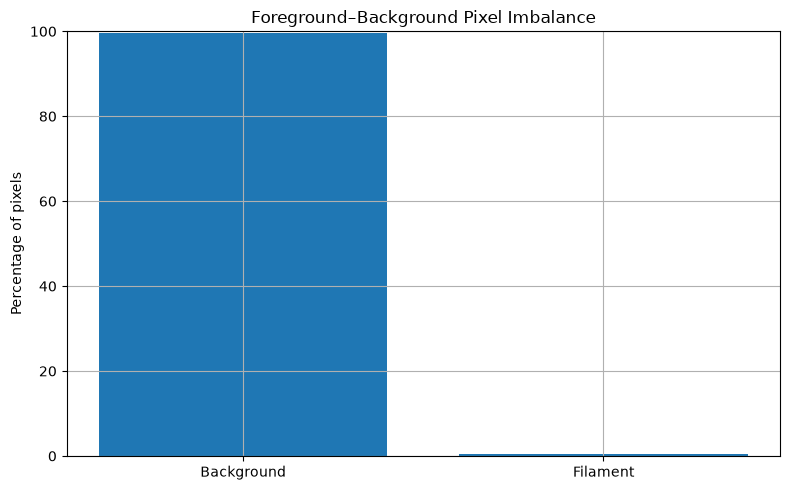

Filament coverage in this calculation: 0.3876%


In [11]:

foreground = 0
total = 0

for p in mask_files:
    m = np.array(Image.open(p))
    foreground += np.count_nonzero(m > 0)
    total += m.size

background = total - foreground

foreground_pct = 100 * foreground / total
background_pct = 100 * background / total

imbalance_df = pd.DataFrame({
    "Class": ["Background", "Filament"],
    "Percentage": [background_pct, foreground_pct]
})

display(imbalance_df)

plt.figure(figsize=(8, 5))
plt.bar(imbalance_df["Class"], imbalance_df["Percentage"])
plt.ylabel("Percentage of pixels")
plt.title("Foreground–Background Pixel Imbalance")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

print(f"Filament coverage in this calculation: {foreground_pct:.4f}%")


## 12. Train vs validation filament-area comparison

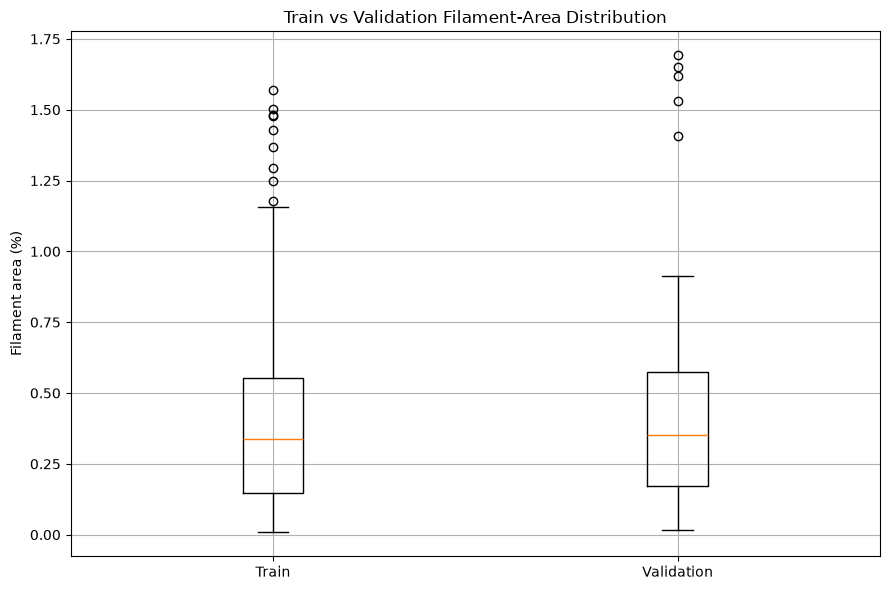

Train mean filament area:      0.3876%
Validation mean filament area: 0.4173%


In [13]:
val_images = image_files(VAL_IMG_DIR)
val_mask_files = image_files(VAL_MASK_DIR)
val_mask_lookup = {p.stem: p for p in val_mask_files}

val_paired = [
    (img, val_mask_lookup[img.stem])
    for img in val_images
    if img.stem in val_mask_lookup
]

train_area = [
    filament_area_percent(mask)
    for _, mask in paired
]

val_area = [
    filament_area_percent(mask)
    for _, mask in val_paired
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    [train_area, val_area],
    tick_labels=["Train", "Validation"]
)

plt.ylabel("Filament area (%)")
plt.title("Train vs Validation Filament-Area Distribution")
plt.tight_layout()
plt.show()

print("Train mean filament area:      %.4f%%" % np.mean(train_area))
print("Validation mean filament area: %.4f%%" % np.mean(val_area))

## 13. Images with smallest and largest filament coverage

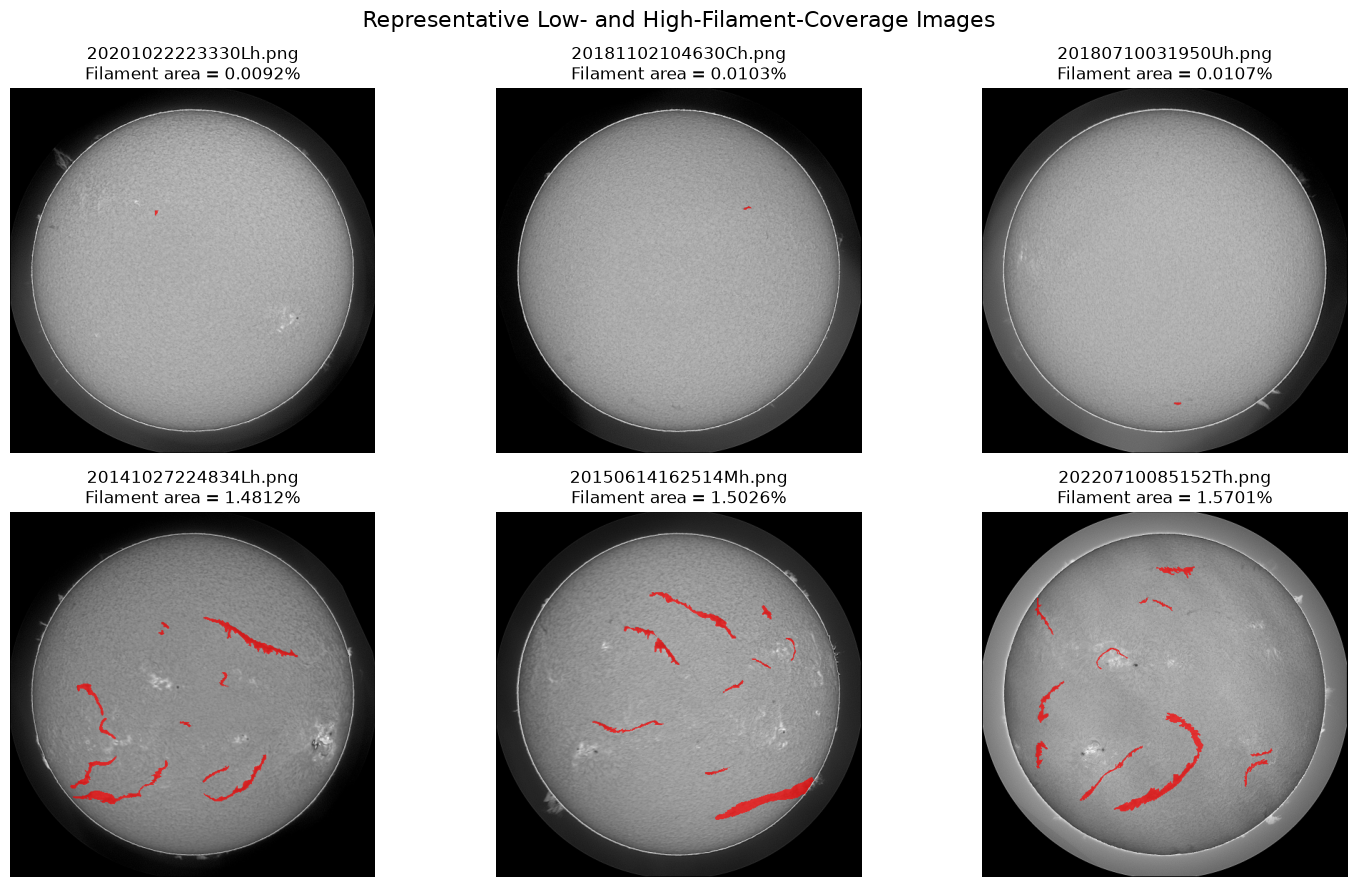

In [14]:

area_sorted = area_df.sort_values("filament_area_percent")

selected_names = list(area_sorted.head(3)["image"]) + list(area_sorted.tail(3)["image"])

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, name in zip(axes.ravel(), selected_names):
    img_path = TRAIN_IMG_DIR / name
    mask_path = TRAIN_MASK_DIR / name

    img = np.array(Image.open(img_path).convert("L"))
    mask = np.array(Image.open(mask_path)) > 0
    pct = 100 * mask.mean()

    ax.imshow(img, cmap="gray")
    overlay = np.zeros((*mask.shape, 4))
    overlay[..., 0] = 1
    overlay[..., 3] = mask.astype(float) * 0.7
    ax.imshow(overlay)

    ax.set_title(f"{name}\nFilament area = {pct:.4f}%")
    ax.axis("off")

plt.suptitle("Representative Low- and High-Filament-Coverage Images", fontsize=16)
plt.tight_layout()
plt.show()


## 14. Observatory-station distribution

Manifest columns:
['filename', 'split', 'station', 'station_name', 'date_captured', 'annotator_count', 'num_filaments_annotated', 'yolo_objects_count', 'filament_pixel_count', 'filament_area_pct', 'classes_present', 'count_left_pixels', 'count_right_pixels', 'count_unidentifiable_pixels', 'count_ambiguous_pixels', 'rel_path_img', 'rel_path_clahe', 'rel_path_mask_multiclass', 'rel_path_mask_binary', 'rel_path_mask_spine', 'rel_path_yolo_label']


,Train,Validation
station,,
Bh,94,24
Ch,100,25
Lh,102,25
Mh,100,25
Th,88,22
Uh,82,20


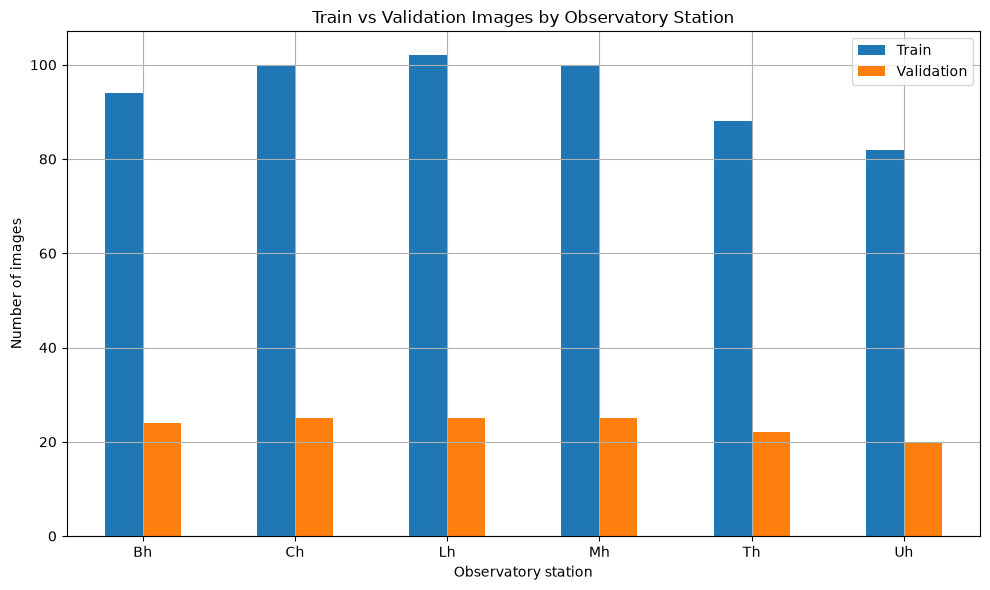

In [15]:

train_manifest = PREPROCESSED_DIR / "metadata" / "train_manifest.csv"
val_manifest = PREPROCESSED_DIR / "metadata" / "val_manifest.csv"

if train_manifest.exists():
    train_m = pd.read_csv(train_manifest)
    val_m = pd.read_csv(val_manifest) if val_manifest.exists() else None

    print("Manifest columns:")
    print(train_m.columns.tolist())

    station_candidates = [
        c for c in train_m.columns
        if "station" in c.lower() or "observ" in c.lower()
    ]

    if station_candidates:
        station_col = station_candidates[0]
        train_counts = train_m[station_col].value_counts().sort_index()

        if val_m is not None and station_col in val_m.columns:
            val_counts = val_m[station_col].value_counts().sort_index()
            station_df = pd.concat(
                [train_counts.rename("Train"), val_counts.rename("Validation")],
                axis=1
            ).fillna(0)

            display(station_df)

            station_df.plot(kind="bar", figsize=(10, 6))
            plt.xlabel("Observatory station")
            plt.ylabel("Number of images")
            plt.title("Train vs Validation Images by Observatory Station")
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()
        else:
            display(train_counts.rename("Train").to_frame())
    else:
        print("No station/observatory column detected.")
else:
    print("Train manifest not found.")


## 15. CLAHE preprocessing examples

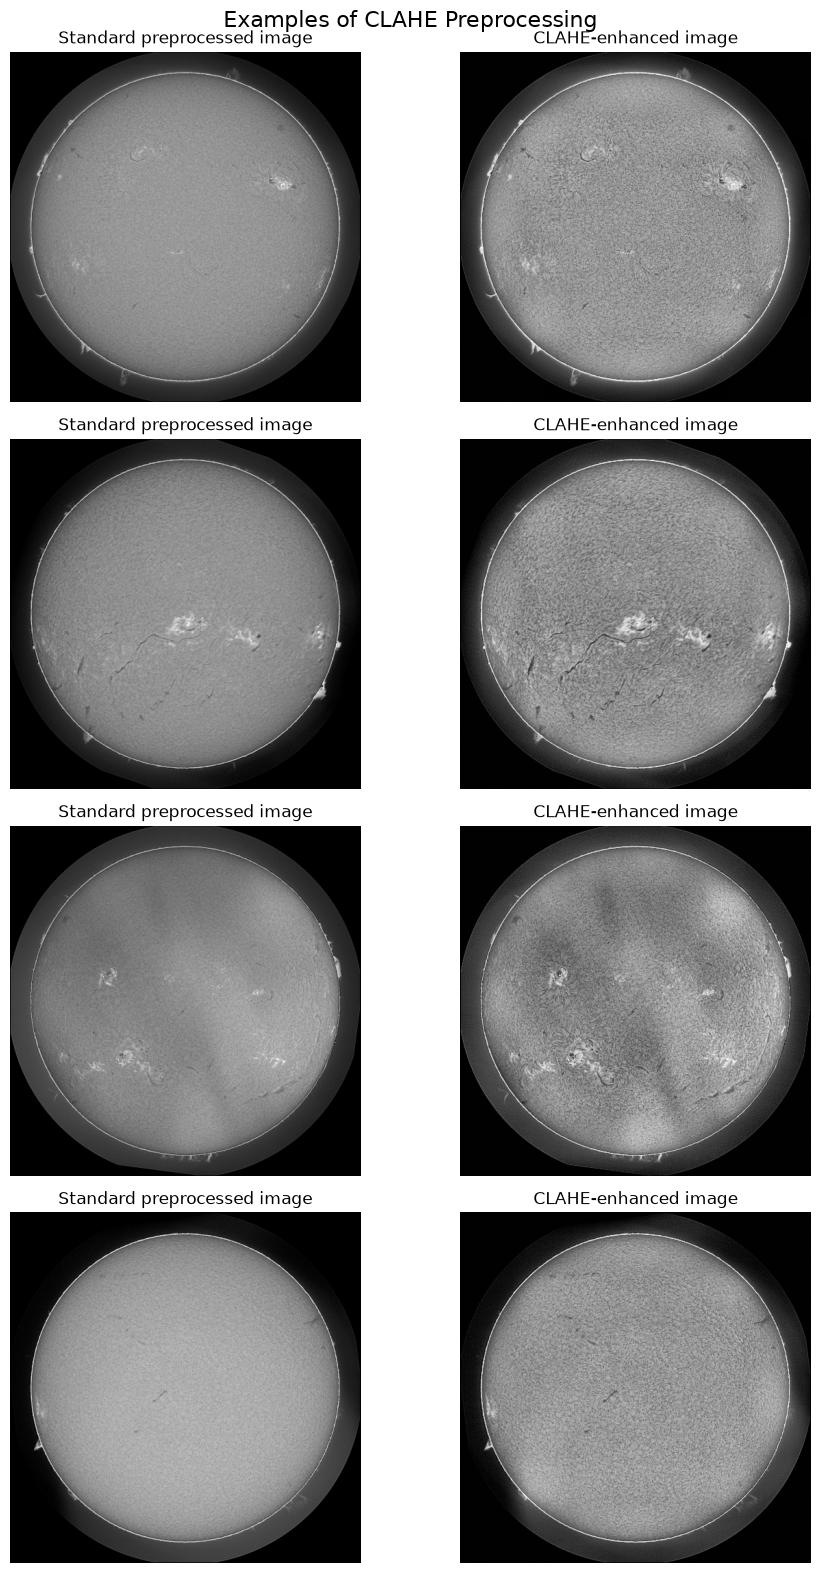

In [16]:

if TRAIN_CLAHE_DIR.exists():
    clahe_files = image_files(TRAIN_CLAHE_DIR)
    clahe_lookup = {p.stem: p for p in clahe_files}

    matched_clahe = [
        (img, clahe_lookup[img.stem])
        for img in train_images
        if img.stem in clahe_lookup
    ]

    random.seed(33)
    clahe_samples = random.sample(matched_clahe, min(4, len(matched_clahe)))

    fig, axes = plt.subplots(len(clahe_samples), 2, figsize=(10, 4 * len(clahe_samples)))
    if len(clahe_samples) == 1:
        axes = np.array([axes])

    for i, (normal_path, clahe_path) in enumerate(clahe_samples):
        normal = Image.open(normal_path).convert("L")
        clahe = Image.open(clahe_path).convert("L")

        axes[i, 0].imshow(normal, cmap="gray")
        axes[i, 0].set_title("Standard preprocessed image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(clahe, cmap="gray")
        axes[i, 1].set_title("CLAHE-enhanced image")
        axes[i, 1].axis("off")

    plt.suptitle("Examples of CLAHE Preprocessing", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("CLAHE directory not found; skipping this section.")


## 16. Duplicate filename/stem check

In [17]:

all_train_stems = [p.stem for p in train_images]
duplicate_stems = pd.Series(all_train_stems).duplicated().sum()

print("Duplicate preprocessed train stems:", duplicate_stems)
print("Unique preprocessed train stems:", len(set(all_train_stems)))


Duplicate preprocessed train stems: 0
Unique preprocessed train stems: 566


## 17. EDA summary


### Key observations for the first review

- The raw solar observations are **2048×2048 grayscale images**.
- The segmentation pipeline uses **512×512** model inputs.
- The project contains **566 training images, 141 validation images and 180 held-out test images** after preprocessing.
- Ground-truth masks are binary and identify filament pixels.
- Filament coverage is very small relative to the background, producing substantial foreground/background imbalance.
- Train and validation filament-area distributions can be compared to inspect whether the split is broadly consistent.
- Observatory-station distribution can be inspected because the project uses station-stratified splitting.
- Intensity and contrast distributions provide basic image-quality/appearance EDA.
- CLAHE examples show the effect of the preprocessing enhancement used by the pipeline.
- Overlay visualizations make the segmentation target easier to understand before discussing model results.

### Link to the U-Net experiment

These EDA observations motivate:
- an encoder–decoder segmentation architecture such as **U-Net**,
- Dice/IoU as important segmentation metrics,
- careful handling of the strong foreground/background imbalance,
- and visual inspection of predicted masks in addition to numerical metrics.
